## 1) Import Libraries

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

## 2) Load the Dataset

In [37]:
df = pd.read_csv("../data/loan_default_dataset.csv")
df.head()

,CustomerID,Gender,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentStatus,MaritalStatus,PreviousDefaults,Defaulted
0,CUST000001,Female,21,132598,49661,48,448,Unemployed,Widowed,1,No
1,CUST000002,Female,22,72729,32954,36,393,Self-employed,Divorced,3,Yes
2,CUST000003,Male,33,41862,10324,24,834,Full-time,Divorced,3,No
3,CUST000004,Male,34,147515,38884,36,756,Part-time,Single,3,No
4,CUST000005,Male,65,80741,35154,48,840,Self-employed,Married,1,Yes


## 3) Clean Data

### 3.1) Check DataTypes and Non-Null Values

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        20000 non-null  object
 1   Gender            20000 non-null  object
 2   Age               20000 non-null  int64 
 3   Income            20000 non-null  int64 
 4   LoanAmount        20000 non-null  int64 
 5   LoanTerm          20000 non-null  int64 
 6   CreditScore       20000 non-null  int64 
 7   EmploymentStatus  20000 non-null  object
 8   MaritalStatus     20000 non-null  object
 9   PreviousDefaults  20000 non-null  int64 
 10  Defaulted         20000 non-null  object
dtypes: int64(6), object(5)
memory usage: 1.7+ MB


### 3.2) Statistical Summary

In [39]:
df.describe()

,Age,Income,LoanAmount,LoanTerm,CreditScore,PreviousDefaults
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,43.682300,84696.258900,27366.920850,36.127200,575.427250,1.995700
std,15.064668,37487.413405,12946.647685,16.902488,158.552694,1.419148
min,18.000000,20011.000000,5001.000000,12.000000,300.000000,0.000000
25%,31.000000,52275.750000,16263.500000,24.000000,439.000000,1.000000
50%,44.000000,84643.000000,27200.000000,36.000000,576.000000,2.000000
75%,57.000000,117177.500000,38449.250000,48.000000,712.000000,3.000000
max,69.000000,149976.000000,49999.000000,60.000000,849.000000,4.000000


### 3.3) Checking Null Values

In [40]:
df.isnull()

,CustomerID,Gender,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentStatus,MaritalStatus,PreviousDefaults,Defaulted
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,False,False,False


In [41]:
df.isnull().sum()

CustomerID          0
Gender              0
Age                 0
Income              0
LoanAmount          0
LoanTerm            0
CreditScore         0
EmploymentStatus    0
MaritalStatus       0
PreviousDefaults    0
Defaulted           0
dtype: int64

### 3.4) Checking Duplicate Rows

In [42]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Length: 20000, dtype: bool

In [43]:
df.duplicated().sum()

np.int64(0)

### 3.4) Checking Age Criteria

In [44]:
df.loc[df.Age < 18]

,CustomerID,Gender,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentStatus,MaritalStatus,PreviousDefaults,Defaulted


### 3.5) Checking Income Criteria

In [45]:
df.loc[df.Income < 0]

,CustomerID,Gender,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentStatus,MaritalStatus,PreviousDefaults,Defaulted


### 3.6) Checking LoanAmount Criteria

In [46]:
df.loc[df.LoanAmount < 0]

,CustomerID,Gender,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentStatus,MaritalStatus,PreviousDefaults,Defaulted


### 3.7) Checking LoanTerm Criteria

In [47]:
df.loc[df.LoanTerm < 0]

,CustomerID,Gender,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentStatus,MaritalStatus,PreviousDefaults,Defaulted


### 3.8) Checking CreditScore Criteria

In [48]:
df.loc[df.CreditScore < 300]

,CustomerID,Gender,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentStatus,MaritalStatus,PreviousDefaults,Defaulted


In [49]:
df.loc[df.CreditScore > 900]

,CustomerID,Gender,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentStatus,MaritalStatus,PreviousDefaults,Defaulted


In [50]:
df.loc[(df.CreditScore < 300) & (df.CreditScore > 900)]

,CustomerID,Gender,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentStatus,MaritalStatus,PreviousDefaults,Defaulted


In [51]:
df.loc[(df.CreditScore < 300) | (df.CreditScore > 900)]

,CustomerID,Gender,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentStatus,MaritalStatus,PreviousDefaults,Defaulted


## 4) Check the Target Distribution

In [70]:
df['Defaulted'].value_counts()

Defaulted
No     14945
Yes     5055
Name: count, dtype: int64

In [71]:
df['Defaulted'].value_counts(normalize=True) * 100

Defaulted
No     74.725
Yes    25.275
Name: proportion, dtype: float64

## 5) Check The Categorical Columns

In [69]:
categorical_cols = ['Gender', 'EmploymentStatus', 'MaritalStatus', 'Defaulted']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Gender:
Gender
Male      10085
Female     9915
Name: count, dtype: int64

EmploymentStatus:
EmploymentStatus
Unemployed       5013
Part-time        5011
Full-time        5003
Self-employed    4973
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Single      5036
Widowed     5014
Married     4996
Divorced    4954
Name: count, dtype: int64

Defaulted:
Defaulted
No     14945
Yes     5055
Name: count, dtype: int64


## 6) Check Numerical Distributions

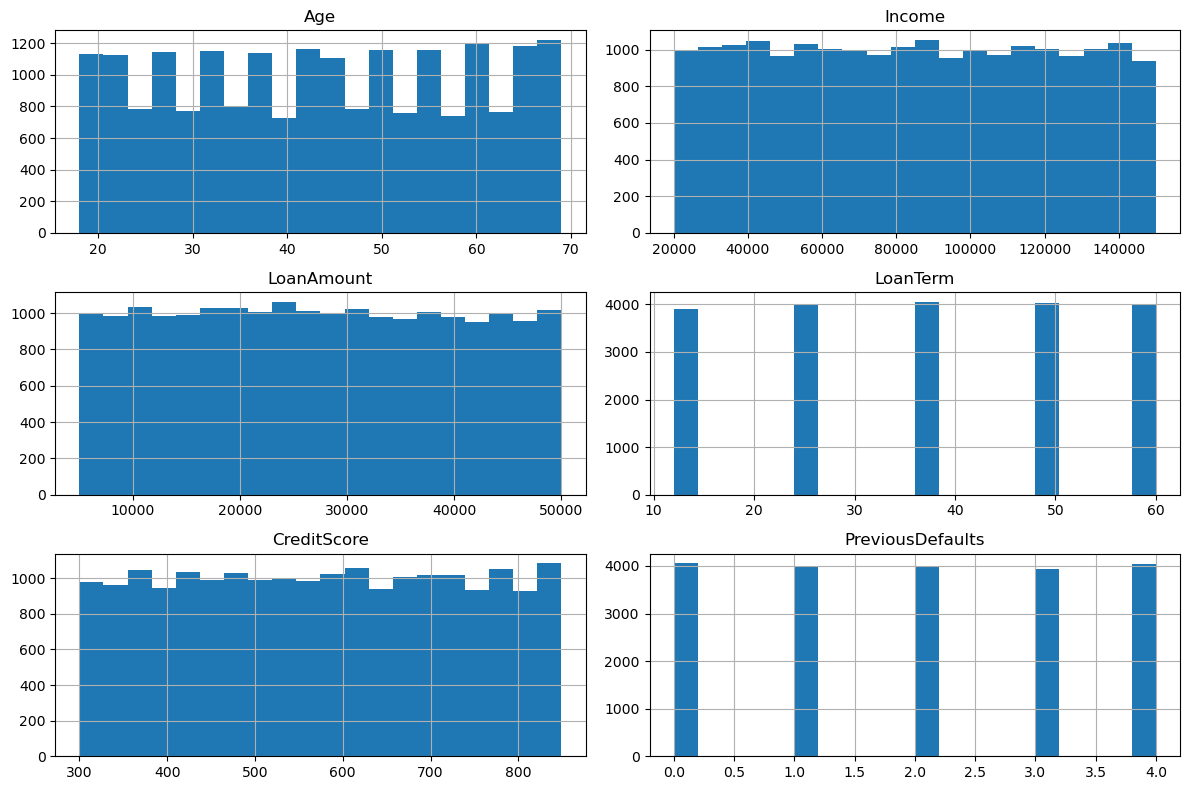

In [120]:
numerical_cols = [
    'Age',
    'Income',
    'LoanAmount',
    'LoanTerm',
    'CreditScore',
    'PreviousDefaults'
]

df[numerical_cols].hist(figsize=(12, 8), bins=20)

plt.tight_layout()
plt.show()

## 7) Check Correlation

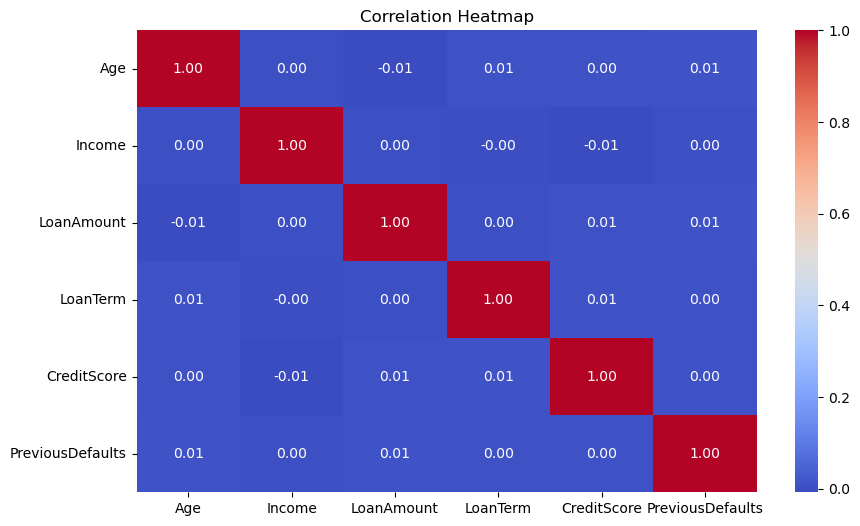

In [121]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

## 8) Categorical Columns to Numerical Values

### 8.1) Using Label Encoder

In [25]:
cols = ['Gender', 'EmploymentStatus', 'MaritalStatus', 'Defaulted']

In [28]:
le = LabelEncoder()

In [30]:
for col in cols:
    df[col] = le.fit_transform(df[col])

In [31]:
df.head()

,CustomerID,Gender,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentStatus,MaritalStatus,PreviousDefaults,Defaulted
0,CUST000001,0,21,132598,49661,48,448,3,3,1,0
1,CUST000002,0,22,72729,32954,36,393,2,0,3,1
2,CUST000003,1,33,41862,10324,24,834,0,0,3,0
3,CUST000004,1,34,147515,38884,36,756,1,2,3,0
4,CUST000005,1,65,80741,35154,48,840,2,1,1,1


### 8.2) Using Map

In [52]:
gender_map = {'Male': 0 , 'Female': 1}
employment_map = {'Unemployed': 0 , 'Self-employed': 1 , 'Part-time': 2 , 'Full-time': 3}
marital_map = {'Single': 0 , 'Married': 1 , 'Divorced': 2 , 'Widowed': 3}
defaulted_map = {'No': 0 , 'Yes': 1}

In [53]:
df['GenderNumeric'] = df['Gender'].map(gender_map)
df['EmploymentNumeric'] = df['EmploymentStatus'].map(employment_map)
df['MaritalNumeric'] = df['MaritalStatus'].map(marital_map)
df['DefaultedNumeric'] = df['Defaulted'].map(defaulted_map)

In [54]:
df.head()

,CustomerID,Gender,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentStatus,MaritalStatus,PreviousDefaults,Defaulted,GenderNumeric,EmploymentNumeric,MaritalNumeric,DefaultedNumeric
0,CUST000001,Female,21,132598,49661,48,448,Unemployed,Widowed,1,No,1,0,3,0
1,CUST000002,Female,22,72729,32954,36,393,Self-employed,Divorced,3,Yes,1,1,2,1
2,CUST000003,Male,33,41862,10324,24,834,Full-time,Divorced,3,No,0,3,2,0
3,CUST000004,Male,34,147515,38884,36,756,Part-time,Single,3,No,0,2,0,0
4,CUST000005,Male,65,80741,35154,48,840,Self-employed,Married,1,Yes,0,1,1,1


## 9) Extract X

In [56]:
X = df[['GenderNumeric', 'Age', 'Income', 'LoanAmount', 'LoanTerm', 'CreditScore', 'EmploymentNumeric', 'MaritalNumeric', 'PreviousDefaults']]

In [58]:
X.head(2)

,GenderNumeric,Age,Income,LoanAmount,LoanTerm,CreditScore,EmploymentNumeric,MaritalNumeric,PreviousDefaults
0,1,21,132598,49661,48,448,0,3,1
1,1,22,72729,32954,36,393,1,2,3


## 10) Extract y

In [92]:
y = df[['DefaultedNumeric']]

In [93]:
y.head(2)

,DefaultedNumeric
0,0
1,1


In [94]:
print("X shape :", X.shape)
print("y shape :", y.shape)

X shape : (20000, 9)
y shape : (20000, 1)


## 11) Train Test Split

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state = 42 , stratify=y)

In [96]:
print("X shape:", X_train.shape)
print("y shape:", X_test.shape)

X shape: (16000, 9)
y shape: (4000, 9)


In [97]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True)*100)
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True)*100)
print(y_test.value_counts())

Training target distribution:
DefaultedNumeric
0                   74.725
1                   25.275
Name: proportion, dtype: float64
DefaultedNumeric
0                   11956
1                    4044
Name: count, dtype: int64

Testing target distribution:
DefaultedNumeric
0                   74.725
1                   25.275
Name: proportion, dtype: float64
DefaultedNumeric
0                   2989
1                   1011
Name: count, dtype: int64


## 12) Create a Model

In [98]:
dtc_model = DecisionTreeClassifier()

## 13) Train the Model

In [99]:
dtc_model.fit(X_train , y_train)

DecisionTreeClassifier()

## 14) Make Sample Predictions

In [105]:
op_arr = dtc_model.predict([[1,	21,	132598,	49661,	48,	448,	0,	3,	1]])
op = op_arr[0]

if op == 0 :
    print("Defaulted : No")
elif op == 1:
    print("Defaulted : Yes")

Defaulted : No


## 15) Make Predictions Using X_test

In [106]:
y_pred = dtc_model.predict(X_test)
y_pred

array([1, 1, 0, ..., 1, 0, 0])

In [107]:
y_test

,DefaultedNumeric
9153,0
4817,0
6322,1
18493,1
13201,0
...,...
13104,0
13166,1
4034,0
5629,0


## 16) Calculate Accuracy

In [118]:
acc_score = accuracy_score(y_test , y_pred)
acc = round(acc_score * 100, 2)
print(f"Accuracy : {acc} %")

Accuracy : 61.38 %


## 17) User Input Predictions

In [112]:
gender = int(input("Enter Gender (Male : 0 , Female : 1)  :  "))
age = int(input("Enter Age  :  "))
income = int(input("Enter Income  :  "))
loan_amount = int(input("Enter Loan Amount  :  "))
loan_term = int(input("Enter Loan Term  :  "))
credit_score = int(input("Enter Credit Score  :  "))
employment_status = int(input("Enter Employment Status (Unemployed : 0 , Self-employed : 1 , Part-time : 2 , Full-time : 3)  :  "))
marital_status = int(input("Enter Marital Status (Single : 0 , Married : 1 , Divorced : 2 , Widowed : 3)  :  "))
previous_defaults = int(input("Enter Previous Defaults  :  "))

op_arr = dtc_model.predict([[gender , age , income , loan_amount , loan_term , credit_score , employment_status , marital_status , previous_defaults]])
op = op_arr[0]

if op == 0:
    print("\n\n Defaulted : No\n🟢 Low Repayment Risk - The Customer is less likely to have difficulty repaying the loan.\nThe Customer might get the Loan")
elif op == 1:
    print(("\n\n Defaulted : Yes\n🔴 High Repayment Risk - The customer may have difficulty repaying the loan.\nThe Customer might not get the Loan"))

Enter Gender (Male : 0 , Female : 1)  :   1
Enter Age  :   24
Enter Income  :   1200000
Enter Loan Amount  :   2200000
Enter Loan Term  :   2
Enter Credit Score  :   610
Enter Employment Status (Unemployed : 0 , Self-employed : 1 , Part-time : 2 , Full-time : 3)  :   1
Enter Marital Status (Single : 0 , Married : 1 , Divorced : 2 , Widowed : 3)  :   1
Enter Previous Defaults  :   2




 Defaulted : Yes
🔴 High Repayment Risk - The customer may have difficulty repaying the loan.
The Customer might not get the Loan
